<a href="https://colab.research.google.com/github/dataprogpy/code-samples/blob/main/starter_files/07_robust_modeling_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Robust Modeling Workflow

In this lesson we extend the six-step workflow to introduce critical modeling best practices. In this session, we will move from classfication to regression.We will reuse the King County Housing dataset introduced in the last module for this purpose.

In [38]:
# tools from standard library
import functools
from pathlib import Path

# tools for data wrangling
import numpy as np
import polars as pl

import geopandas as gpd

# plotting tools
import matplotlib.pyplot as plt

# pipeline and transformers
from sklearn.pipeline import (
    Pipeline,
    make_pipeline,
    )
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    FunctionTransformer,
    )
from sklearn.impute import SimpleImputer

# models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor

# metrics for evaluation
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

# cross validation and dataset splitter
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    cross_validate,
    validation_curve,
    GridSearchCV,
    KFold
    )

# base types for custom transformer
from sklearn.base import BaseEstimator, TransformerMixin

# sklearn config to outpur polars dataframes
from sklearn import set_config
set_config(transform_output='polars')


In [3]:
data_root = Path("/content/drive/MyDrive/dataprogpy/data")
house_data_path = Path("kc_house_data.csv")
schdst_file_path = Path("School_Districts_in_King_County___schdst_area/School_Districts_in_King_County___schdst_area.shp")

In [4]:
kc_schdst = gpd.read_file(data_root / schdst_file_path) # school district shapes

In [5]:
# Load the dataset
raw = pl.read_csv(data_root / house_data_path)
print(kc_schdst.columns)
raw.head()

Index(['OBJECTID', 'SCHDST', 'NAME', 'DSTNUM', 'Shape_Leng', 'Shape_Area',
       'geometry'],
      dtype='object')


id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
i64,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,i64
7129300520,"""20141013T000000""",221900.0,3,1.0,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
6414100192,"""20141209T000000""",538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.721,-122.319,1690,7639
5631500400,"""20150225T000000""",180000.0,2,1.0,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2487200875,"""20141209T000000""",604000.0,4,3.0,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
1954400510,"""20150218T000000""",510000.0,3,2.0,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [6]:
raw_pd = raw.to_pandas()
raw_pd = gpd.GeoDataFrame(
        raw_pd,
        geometry=gpd.points_from_xy(raw_pd.long, raw_pd.lat),
        crs="EPSG:4326"
        ).sjoin(
            kc_schdst.to_crs("EPSG:4326"),
            how="left",
            predicate="intersects")
print(raw_pd.shape)
# raw_pd.head()
raw = pl.from_pandas(raw_pd[raw.columns + ["NAME"]]).select(
    pl.col(raw.columns),
    pl.col("NAME").alias("school_district")
)
print(raw.shape)
print(raw.columns)
raw.head()

(21613, 29)
(21613, 22)
['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 'school_district']


id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,school_district
i64,str,f64,i64,f64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,i64,str
7129300520,"""20141013T000000""",221900.0,3,1.0,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,"""Seattle"""
6414100192,"""20141209T000000""",538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.721,-122.319,1690,7639,"""Seattle"""
5631500400,"""20150225T000000""",180000.0,2,1.0,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062,"""Northshore"""
2487200875,"""20141209T000000""",604000.0,4,3.0,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,"""Seattle"""
1954400510,"""20150218T000000""",510000.0,3,2.0,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,"""Lake Washington"""


In [7]:
def tweak_housing(df):
    return (
        df.with_columns(
            zipcode=pl.col('zipcode').cast(pl.String).cast(pl.Categorical),
            school_district=pl.col('school_district').cast(pl.Categorical),
            date=pl.col('date').str.strptime(pl.Date, format="%Y%m%dT%H%M%S"),
            yr_renovated=pl.col('yr_renovated').replace(0, None),
            ).select(
                pl.col(['id', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'school_district','lat', 'long', 'sqft_living15', 'sqft_lot15', 'date', ])
            )
    )

tweak_transformer = FunctionTransformer(tweak_housing)

In [8]:
numeric_features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
                    'floors', 'waterfront', 'view', 'condition', 'grade',
                    'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated',
                    'lat', 'long', 'sqft_living15', 'sqft_lot15', ]

numeric_transformer = Pipeline(
    steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
    ])

In [9]:
categorical_features = ['zipcode', 'school_district']

categorical_transformer = Pipeline(
    steps=[
         ('onehot', OneHotEncoder(handle_unknown='ignore',
                              sparse_output=False)),
    # ('target', TargetEncoder()),
    # ('std', StandardScaler()),
    ])

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat',categorical_transformer, categorical_features),
        ],
        # remainder='passthrough',
    )

In [17]:
lr =  LinearRegression()
X = raw
y = raw.select('price')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

lr_pipe = Pipeline(steps=[
    ('tweak', tweak_transformer),
    ('preprocessor', preprocessor),
    ('lr', lr),
    ])

lr_pipe.fit(X_train, y_train)
print(lr_pipe.score(X_test, y_test))
lr_pipe

0.8010475068148948


Pipeline(steps=[('tweak',
                 FunctionTransformer(func=<function tweak_housing at 0x780cd7b902c0>)),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['bedrooms', 'bathrooms',
                                                   'sqft_living', 'sqft_lot',
                                                   'floors', 'waterfront',
                                                   'view', 'condition', 'grade',
                                                   'sqft_above',
                                                   'sqft_basement', 'yr_built',
                                                   'yr_renovated', 'lat',
                                                   'long', 'sqft_living15',
                                                   'sqft_lot15']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['zipcode',
                                                   'school_district'])])),
                ('lr', LinearRegression())])

In [21]:
def train_test(model, test_size=0.4, random_state=42):
  X = raw
  y = raw.select('price')

  X_train, X_test, y_train, y_test = train_test_split(
      X,
      y,
      test_size=test_size,
      random_state=random_state)



  pipeline = make_pipeline(tweak_transformer, preprocessor, model)
  pipeline.fit(X_train, y_train)
  print(pipeline.score(X_test, y_test))
  return pipeline

In [28]:
train_test(DummyRegressor(strategy='median'), 0.4,)

-0.0597493285675994


Pipeline(steps=[('functiontransformer',
                 FunctionTransformer(func=<function tweak_housing at 0x780cd7b902c0>)),
                ('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['bedrooms', 'bathrooms',
                                                   'sqft_living', 'sqft_lot',
                                                   'floors', 'waterfront',
                                                   'view', 'condition', 'grade',
                                                   'sqft_above',
                                                   'sqft_basement', 'yr_built',
                                                   'yr_renovated', 'lat',
                                                   'long', 'sqft_living15',
                                                   'sqft_lot15']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['zipcode',
                                                   'school_district'])])),
                ('dummyregressor', DummyRegressor(strategy='median'))])

In [22]:
train_test(lr, 0.4,)

0.8010475068148948


Pipeline(steps=[('functiontransformer',
                 FunctionTransformer(func=<function tweak_housing at 0x780cd7b902c0>)),
                ('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['bedrooms', 'bathrooms',
                                                   'sqft_living', 'sqft_lot',
                                                   'floors', 'waterfront',
                                                   'view', 'condition', 'grade',
                                                   'sqft_above',
                                                   'sqft_basement', 'yr_built',
                                                   'yr_renovated', 'lat',
                                                   'long', 'sqft_living15',
                                                   'sqft_lot15']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['zipcode',
                                                   'school_district'])])),
                ('linearregression', LinearRegression())])

In [31]:
dt_pipe = train_test(DecisionTreeRegressor(max_depth=5, random_state=42), 0.6,)

0.6970429193462337


In [32]:
dt_pipe.named_steps['decisiontreeregressor'].get_depth()

param_range = range(1, 20)
train_scores, test_scores = validation_curve(
    dt_pipe, X_train, y_train, param_name="decisiontreeregressor__max_depth", param_range=param_range,
    scoring="neg_mean_squared_error", n_jobs=1)

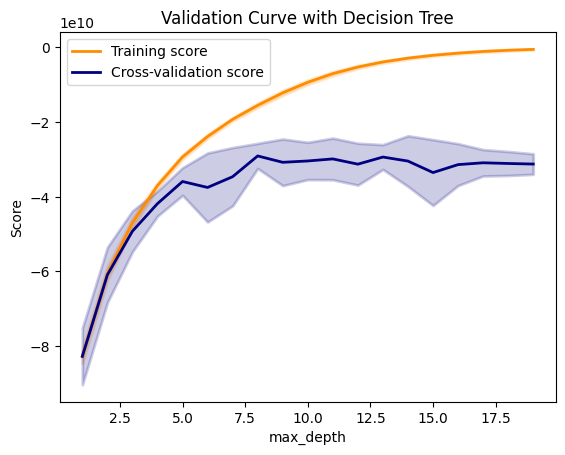

In [34]:
# make a validation curve from train_scores and test_scores

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.title("Validation Curve with Decision Tree")
plt.xlabel("max_depth")
plt.ylabel("Score")
#plt.ylim(-1, 0)
lw = 2
plt.plot(param_range, train_scores_mean, label="Training score",
             color="darkorange", lw=lw)
plt.fill_between(param_range, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.2,
                 color="darkorange", lw=lw)
plt.plot(param_range, test_scores_mean, label="Cross-validation score",
                color="navy", lw=lw)

plt.fill_between(param_range, test_scores_mean - test_scores_std,
                    test_scores_mean + test_scores_std, alpha=0.2,
                    color="navy", lw=lw)
plt.legend(loc="best")

In [52]:
from sklearn.feature_selection import RFECV
# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import StratifiedKFold

min_features_to_select = 1  # Minimum number of features to consider
dt = DecisionTreeRegressor()
cv = KFold(5)

rfecv = RFECV(
    estimator=dt,
    step=1,
    cv=cv,
    # scoring="accuracy",
    min_features_to_select=min_features_to_select,
    # n_jobs=2,
)
pipe = Pipeline(steps=[
    ('tweak', tweak_transformer),
    ('preprocessor', preprocessor),
    ('rfecv', rfecv),
    ])
pipe.fit(X, y)

print(f"Optimal number of features: {pipe.named_steps['rfecv'].n_features_}")

Optimal number of features: 97


In [49]:
from sklearn.linear_model import RidgeCV

ridge = RidgeCV(alphas=np.logspace(-6, 6, num=5))
pipe  = make_pipeline(tweak_transformer, preprocessor, ridge)
pipe.fit(X_train, y_train)

importance = np.abs(pipe.named_steps['ridgecv'].coef_)
importance

array([2.50584203e+04, 2.07080097e+04, 8.47505054e+04, 9.35768143e+03,
       2.15333569e+04, 5.03376578e+04, 4.39637951e+04, 1.45202541e+04,
       6.83303292e+04, 8.64503893e+04, 1.30969711e+04, 2.55581846e+04,
       6.72108155e+03, 5.58794425e+04, 1.46098668e+04, 1.00274476e+04,
       2.20442048e+03, 6.49777982e+04, 2.59598023e+04, 7.96486906e+04,
       4.40167995e+05, 2.09370444e+03, 9.46064943e+03, 5.45985607e+04,
       5.93292085e+04, 4.37516606e+04, 1.03425648e+05, 9.05931757e+04,
       1.39377264e+05, 6.94204340e+03, 1.11657804e+05, 6.99817730e+03,
       1.65817798e+04, 1.10593372e+05, 2.18493776e+04, 6.96225764e+04,
       8.23799164e+04, 8.56867801e+04, 1.19902903e+05, 6.33818656e+04,
       2.67777763e+04, 8.11375541e+05, 4.55771237e+05, 7.27962184e+04,
       9.64610586e+03, 1.22846977e+04, 3.29968709e+04, 9.84198746e+04,
       6.76182092e+04, 8.99081097e+04, 8.36703971e+04, 3.14673134e+04,
       3.33010581e+05, 7.05623155e+04, 3.51503241e+04, 4.09555210e+04,
      

In [50]:
dir(pipe.named_steps['ridgecv'])

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_check_feature_names',
 '_check_n_features',
 '_decision_function',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_scorer',
 '_get_tags',
 '_more_tags',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_set_intercept',
 '_store_cv_results',
 '_validate_data',
 '_validate_

In [ ]:

# importance = np.abs(pipe.ridgecv__coef_)

plt.bar(height=importance, x=)
plt.title("Feature importances via coefficients")
plt.show()

In [47]:
pipe.named_steps

{'functiontransformer': FunctionTransformer(func=<function tweak_housing at 0x780cd7b902c0>),
 'columntransformer': ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('imputer',
                                                   SimpleImputer(strategy='median')),
                                                  ('scaler', StandardScaler())]),
                                  ['bedrooms', 'bathrooms', 'sqft_living',
                                   'sqft_lot', 'floors', 'waterfront', 'view',
                                   'condition', 'grade', 'sqft_above',
                                   'sqft_basement', 'yr_built', 'yr_renovated',
                                   'lat', 'long', 'sqft_living15',
                                   'sqft_lot15']),
                                 ('cat',
                                  Pipeline(steps=[('onehot',
                                                   OneHotEncoder(handle_unknown='ignore',

In [37]:
param_grid = {
    f'{"DecisionTreeRegressor".lower()}__max_depth': [3, 6, 9],
    f'{"DecisionTreeRegressor".lower()}__min_samples_split': [10, 20, 100],
    f'{"DecisionTreeRegressor".lower()}__min_samples_leaf': [10, 20, 100],
}
dt_pipe = train_test(DecisionTreeRegressor())
grid_search = GridSearchCV(dt_pipe, param_grid, cv=5)
grid_search.fit(X_train, y_train)

0.755525238972129


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('functiontransformer',
                                        FunctionTransformer(func=<function tweak_housing at 0x780cd7b902c0>)),
                                       ('columntransformer',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['bedrooms',
                                                                          'bathrooms',
                                                                          'sqft_living',
                                                                          'sqft_lot',
                                                                          'floors',
                                                                          'waterf...
                                                                          'sqft_lot15']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['zipcode',
                                                                          'school_district'])])),
                                       ('decisiontreeregressor',
                                        DecisionTreeRegressor())]),
             param_grid={'decisiontreeregressor__max_depth': [3, 6, 9],
                         'decisiontreeregressor__min_samples_leaf': [10, 20,
                                                                     100],
                         'decisiontreeregressor__min_samples_split': [10, 20,
                                                                      100]})

In [41]:
pl.DataFrame(grid_search.best_params_)

decisiontreeregressor__max_depth,decisiontreeregressor__min_samples_leaf,decisiontreeregressor__min_samples_split
i64,i64,i64
9,10,20


In [42]:
dt_pipe = make_pipeline(
    tweak_transformer,
    preprocessor,
    DecisionTreeRegressor(random_state=42))
dt_pipe.set_params(**grid_search.best_params_)
print(grid_search.best_params_)
dt_pipe.fit(X_train, y_train)
dt_pipe.score(X_test, y_test)

{'decisiontreeregressor__max_depth': 9, 'decisiontreeregressor__min_samples_leaf': 10, 'decisiontreeregressor__min_samples_split': 20}


0.7670744393055061

## References

1. [Comparing cross-validation strategies](https://scikit-learn.org/stable/auto_examples/model_selection/plot_cv_indices.html)
1. [Applied Machine Learning: Foundations](https://www.linkedin.com/learning/applied-machine-learning-foundations-21404006) - LinkedIn Learning course